In [12]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Wczytanie zbioru IRIS
Dane dzielimy na:
- **X_iris** – cechy (długość/szerokość działki i płatka)
- **y_iris** – etykiety klas (gatunek irysa)

In [13]:
iris_repo = fetch_ucirepo(id=53)

X_iris = iris_repo.data.features
y_iris = iris_repo.data.targets

df_iris = pd.concat([X_iris, y_iris], axis=1)
df_iris.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Analiza zbioru i wizualizacja rozkładu danych
Sprawdzamy rozmiar zbioru oraz podstawowe statystyki opisowe:

In [14]:
print(f"Number of rows: {len(df_iris)}")
print(f"Number of attributes: {len(X_iris.columns)}")
print(f"\nStatistics:")
df_iris.describe()

Number of rows: 150
Number of attributes: 4

Statistics:


,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Zbiór zawiera 150 próbek które są opisane 4 cechami numerycznymi

- sepal length (długość działki)
- sepal width (szerokość działki)
- petal length (długość płatka)
- petal width (szerokość płatka)


In [15]:
print("\nMissing values:")
print(df_iris.isnull().sum())


Missing values:
sepal length    0
sepal width     0
petal length    0
petal width     0
class           0
dtype: int64


Classes: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_61772/1054882043.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_iris, x='class', palette='Set1')


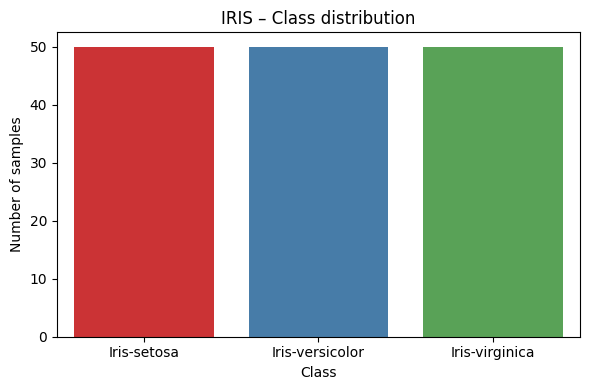

In [16]:
print(f"Classes: {df_iris['class'].unique()}")
print(f"\nClass distribution:")
print(df_iris['class'].value_counts())


plt.figure(figsize=(6, 4))
sns.countplot(data=df_iris, x='class', palette='Set1')
plt.title('IRIS – Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

Zbiór IRIS zawiera 3 gatunki irysów:
- *Iris-setosa*
- *Iris-versicolor*
- *Iris-virginica*

Każdy gatunek reprezentowany jest przez dokładnie 50 próbek

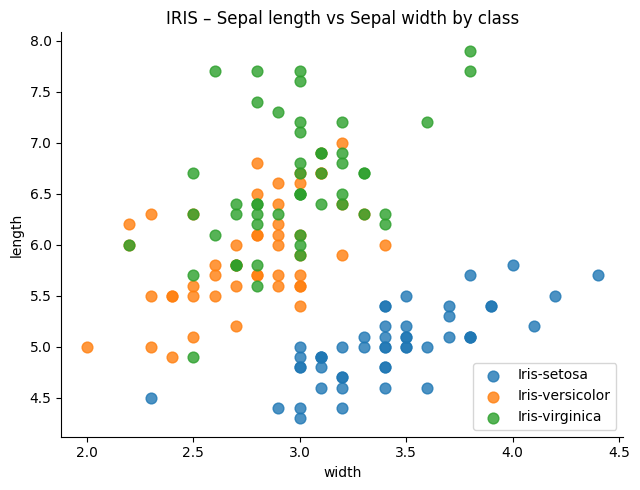

In [17]:
sns.lmplot(
    data=df_iris,
    x='sepal width',
    y='sepal length',
    hue='class',
    height=5,
    aspect=1.3,
    fit_reg=False,
    scatter_kws={'s': 60},
    legend=False
)
plt.legend(
    loc='lower right', 
    title=None
)

plt.title('IRIS – Sepal length vs Sepal width by class')
plt.xlabel('width')
plt.ylabel('length')


plt.tight_layout()
plt.show()

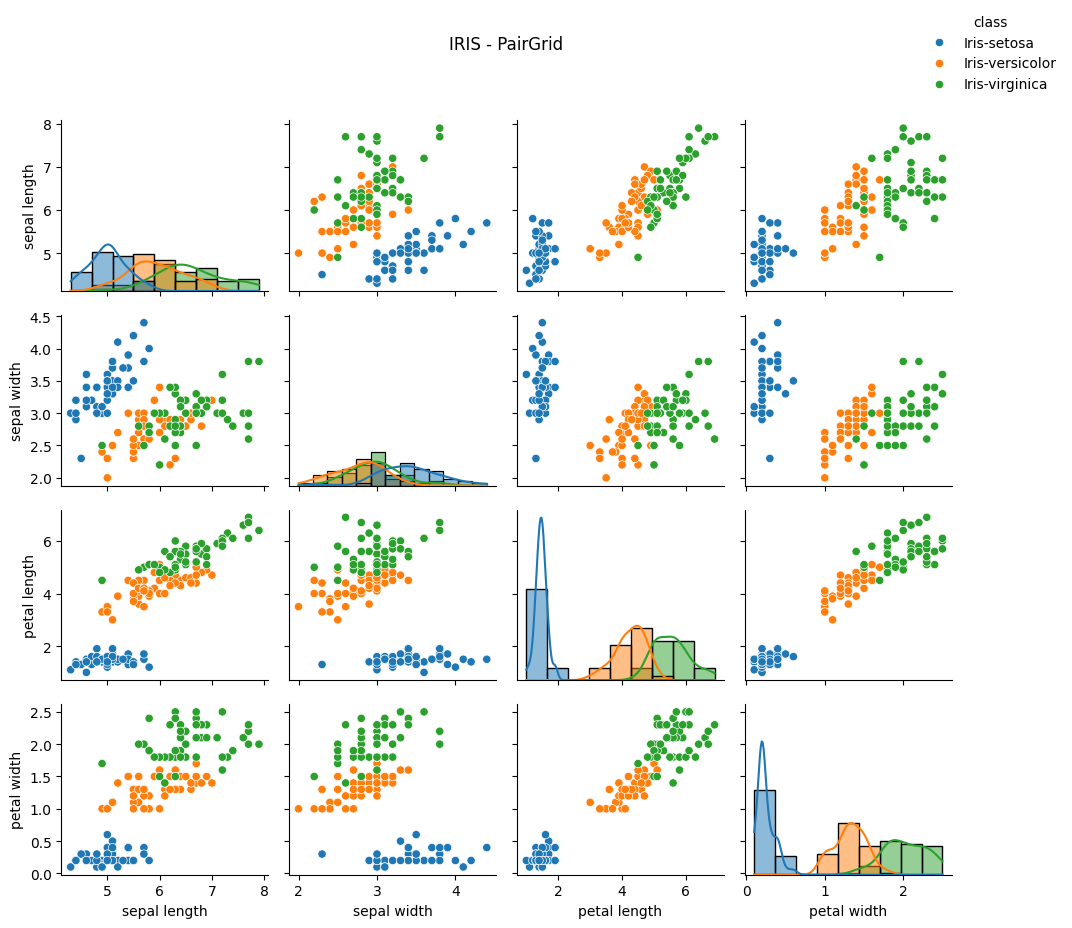

In [18]:
g = sns.PairGrid(df_iris, hue='class', height=2.2)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=True)
g.add_legend(title='class', bbox_to_anchor=(1.05, 1))
g.figure.suptitle('IRIS - PairGrid', y=1.02)
plt.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()

## Użycie PCA 

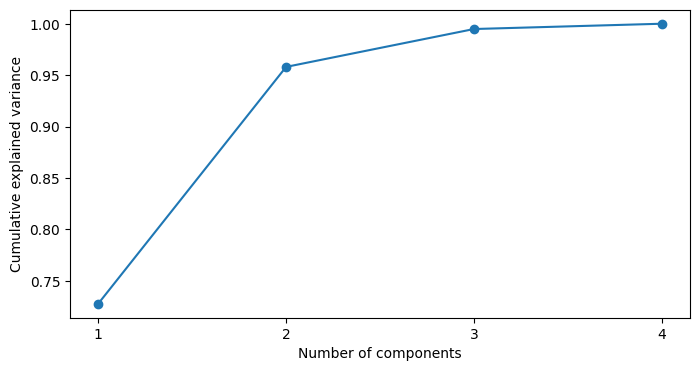

In [19]:
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

pca_full = PCA()
pca_full.fit(X_iris_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.xticks(range(1, len(pca_full.explained_variance_ratio_)+1))
plt.show()

In [20]:
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%} of variance kept")

components_df = pd.DataFrame(
    pca.components_,
    columns=X_iris.columns,
    index=['PC1', 'PC2']
)
print(components_df)

PC1 explains: 72.77% of variance
PC2 explains: 23.03% of variance
Total: 95.80% of variance kept
     sepal length  sepal width  petal length  petal width
PC1      0.522372    -0.263355      0.581254     0.565611
PC2      0.372318     0.925556      0.021095     0.065416


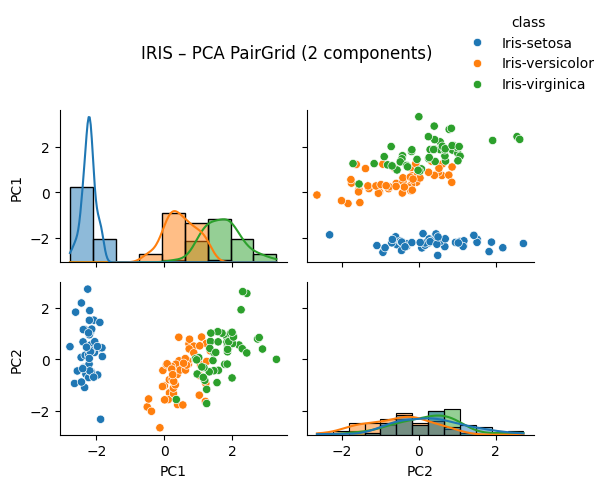

In [22]:
df_pca = pd.DataFrame(X_iris_pca, columns=['PC1', 'PC2'])
df_pca['class'] = y_iris.values.ravel()

g = sns.PairGrid(df_pca, hue='class', height=2.2)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=True)
g.add_legend(title='class', bbox_to_anchor=(1.05, 1))
g.figure.suptitle('IRIS – PCA PairGrid (2 components)', y=1.02)
plt.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()